### CAPSTONE PROJECT

As a performance engineer, I want to build a predictive model that estimates system resource usage—such as CPU and memory utilization—based on the distribution of API usage within an application. Currently, predicting how different API load mixes will impact system resources requires extensive performance testing with multiple load distributions.

This project will use Linear Regression (and possibly other regression methods) to model the relationship between API usage patterns and resulting resource consumption. Given input data describing the throughput and response time across different APIs, the model will predict the expected resource usage. This will help in capacity planning and reduce the need for repeated, costly performance testing scenarios.

**PROBLEM STATEMENT AND APPROACH**

Can we accurately predict system resource utilization (CPU and memory) based on the throughput and response time across different APIs within an application using regression models?

**Expected Data Source**

The test data is obtained from Argus metrics and includes performance metrics for three APIs, along with Pod CPU and heap memory usage. It spans a 7-day period, where each row represents the average CPU usage and average heap memory percentage recorded at 5-second intervals. Below are the columns in the CSV file along with their descriptions:

| Column | Description |
|----------|----------|
| timestamp | Unix timestamp |
| search_api_throughput | Search User api throughput (requests/sec) |
| search_api_avg_ms | Search User api average response time in milliseconds  |
| insert_api_throughput | Insert User api throughput (requests/sec) |
| insert_api_avg_ms | Insert User api average response time in milliseconds |
| graph_api_throughput | User Graph api throughput (requests/sec) |
| graph_api_avg_ms | User Graph api average response time in milliseconds |
| cpu_core | CPU Cores used during that interval. It will be a whole number |
| heap_memory_perc | Heap Memory used as percentage during that interval |    

**Techniques to be used in Analysis**

Data Preparation: Clean, Normalize, Scaling etc.. Model Techniques: Linear regression as base model, Regularization using Lasso or Ridge, Polynomial Regression for non-linear features Metrics: Coef, MSE/RMSE, Cross-validation

**Expected Results**

The model should identify which APIs have the strongest impact on CPU and memory usage. Resource usage will likely increase linearly with certain APIs but may show nonlinear effects under high load. The model will allow estimation of system resource usage for new API load distributions without running new load tests.

**Why?**

Performance testing is expensive and time-consuming. Capacity planning today relies heavily on manual experiments. Predictive modeling can help Reduce Testing cycles and Support proactive scaling decisions

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [58]:
# Load data
df = pd.read_csv("api_perf_metrics.csv")
df = df.sort_values("timestamp")
df.head()

,timestamp,search_api_throughput,search_api_avg_ms,insert_api_throughput,insert_api_avg_ms,graph_api_throughput,graph_api_avg_ms,cpu_core,heap_memory_perc
0,1772341200,23,84,6,148,5,172,1,65
1,1772341205,23,82,7,138,9,107,1,65
2,1772341210,24,81,7,136,10,97,1,65
3,1772341215,25,78,7,139,11,85,1,65
4,1772341220,24,80,7,134,9,107,1,65


In [59]:
# Basic checks
print(df.shape)
print(df.isna().sum())
display(df.describe().T)

(120999, 9)
timestamp                0
search_api_throughput    0
search_api_avg_ms        0
insert_api_throughput    0
insert_api_avg_ms        0
graph_api_throughput     0
graph_api_avg_ms         0
cpu_core                 0
heap_memory_perc         0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
timestamp,120999.0,1.772644e+09,174647.734741,1.772341e+09,1.772492e+09,1.772644e+09,1.772795e+09,1.772946e+09
search_api_throughput,120999.0,1.759381e+02,105.694496,1.100000e+01,7.200000e+01,1.680000e+02,2.570000e+02,8.570000e+02
search_api_avg_ms,120999.0,7.106022e+01,7.197312,2.700000e+01,6.700000e+01,6.900000e+01,7.200000e+01,1.140000e+02
insert_api_throughput,120999.0,1.076413e+02,64.789978,6.000000e+00,5.700000e+01,1.010000e+02,1.590000e+02,2.250000e+02
insert_api_avg_ms,120999.0,1.162141e+02,6.292992,1.060000e+02,1.130000e+02,1.150000e+02,1.180000e+02,3.190000e+02
graph_api_throughput,120999.0,1.448920e+02,82.126434,5.000000e+00,7.000000e+01,1.460000e+02,2.130000e+02,5.520000e+02
graph_api_avg_ms,120999.0,9.218317e+01,5.293743,4.300000e+01,8.900000e+01,9.200000e+01,9.500000e+01,1.720000e+02
cpu_core,120999.0,3.459797e+00,1.091169,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,6.000000e+00
heap_memory_perc,120999.0,5.433714e+01,18.532831,1.000000e+01,4.100000e+01,5.500000e+01,6.900000e+01,8.900000e+01


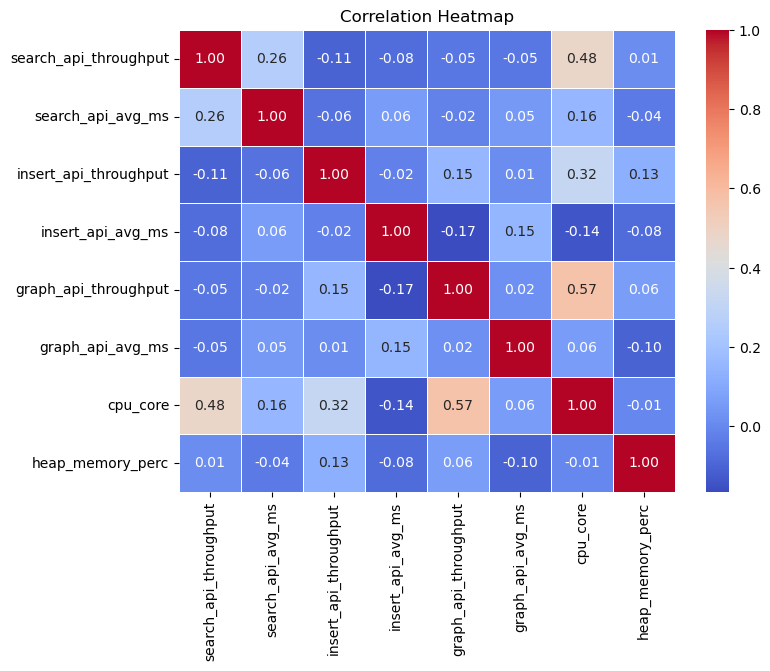

In [60]:

numeric_cols = [
    "search_api_throughput",
    "search_api_avg_ms",
    "insert_api_throughput",
    "insert_api_avg_ms",
    "graph_api_throughput",
    "graph_api_avg_ms",
    "cpu_core",
    "heap_memory_perc"
]

# Correlation matrix
corr = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

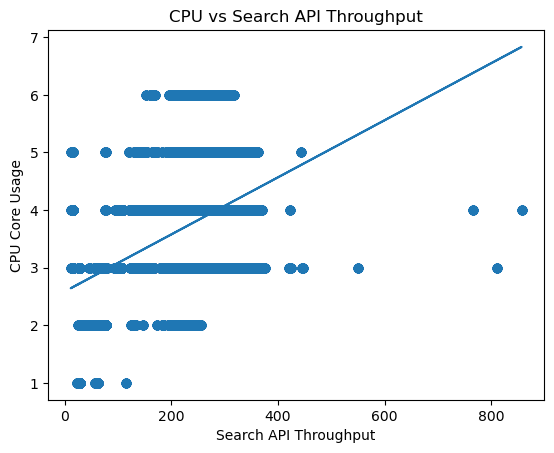

In [61]:
# Extract variables
x = df["search_api_throughput"]
y = df["cpu_core"]

# Create scatter plot
plt.figure()
plt.scatter(x, y)

# Add regression line (trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# Labels and title
plt.xlabel("Search API Throughput")
plt.ylabel("CPU Core Usage")
plt.title("CPU vs Search API Throughput")

plt.show()

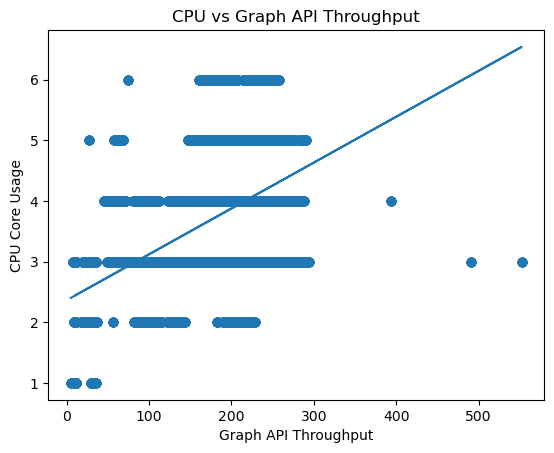

In [62]:
# Extract variables
x = df["graph_api_throughput"]
y = df["cpu_core"]

# Create scatter plot
plt.figure()
plt.scatter(x, y)

# Add regression line (trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# Labels and title
plt.xlabel("Graph API Throughput")
plt.ylabel("CPU Core Usage")
plt.title("CPU vs Graph API Throughput")

plt.show()

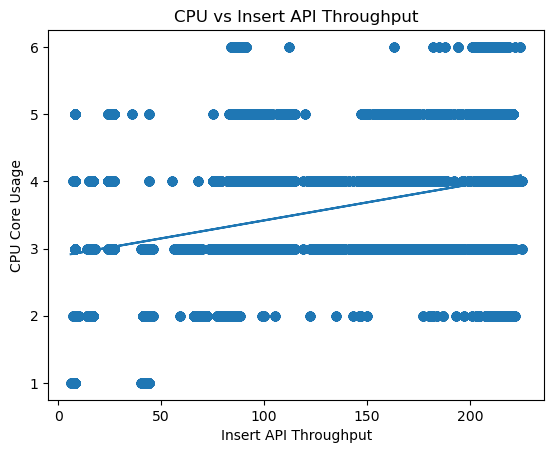

In [63]:
# Extract variables
x = df["insert_api_throughput"]
y = df["cpu_core"]

# Create scatter plot
plt.figure()
plt.scatter(x, y)

# Add regression line (trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# Labels and title
plt.xlabel("Insert API Throughput")
plt.ylabel("CPU Core Usage")
plt.title("CPU vs Insert API Throughput")

plt.show()

### CPU and API Relationship Analysis

**After Reviewing above 3 charts, it clearly shows that Graph API has highest correlation and Insert API has lowest correlation. In real world, the combination of the API load will make a difference to CPU core usage. Hence adding them together and then we need to find the correlation.**

In [64]:
# Feature engineering (API load mix % + totals)
throughput_cols = ["search_api_throughput","insert_api_throughput","graph_api_throughput"]
response_time_cols  = ["search_api_avg_ms","insert_api_avg_ms","graph_api_avg_ms"]

df["total_throughput"] = df[throughput_cols].sum(axis=1)
df["avg_response_time"] = df[response_time_cols].mean(axis=1)

for c in throughput_cols:
    df[c.replace("_throughput", "_load_pct")] = (df[c] / df["total_throughput"]) * 100

load_pct_cols = [c.replace("_avg_ms", "_load_pct") for c in response_time_cols]
display(df[load_pct_cols + ["total_throughput","avg_response_time","cpu_core","heap_memory_perc"]].head())


,search_api_load_pct,insert_api_load_pct,graph_api_load_pct,total_throughput,avg_response_time,cpu_core,heap_memory_perc
0,67.647059,17.647059,14.705882,34,134.666667,1,65
1,58.974359,17.948718,23.076923,39,109.000000,1,65
2,58.536585,17.073171,24.390244,41,104.666667,1,65
3,58.139535,16.279070,25.581395,43,100.666667,1,65
4,60.000000,17.500000,22.500000,40,107.000000,1,65


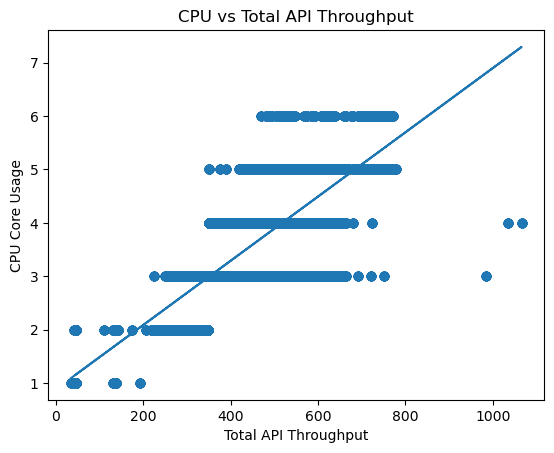

In [65]:
# Extract variables
x = df["total_throughput"]
y = df["cpu_core"]

# Create scatter plot
plt.figure()
plt.scatter(x, y)

# Add regression line (trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# Labels and title
plt.xlabel("Total API Throughput")
plt.ylabel("CPU Core Usage")
plt.title("CPU vs Total API Throughput")

plt.show()

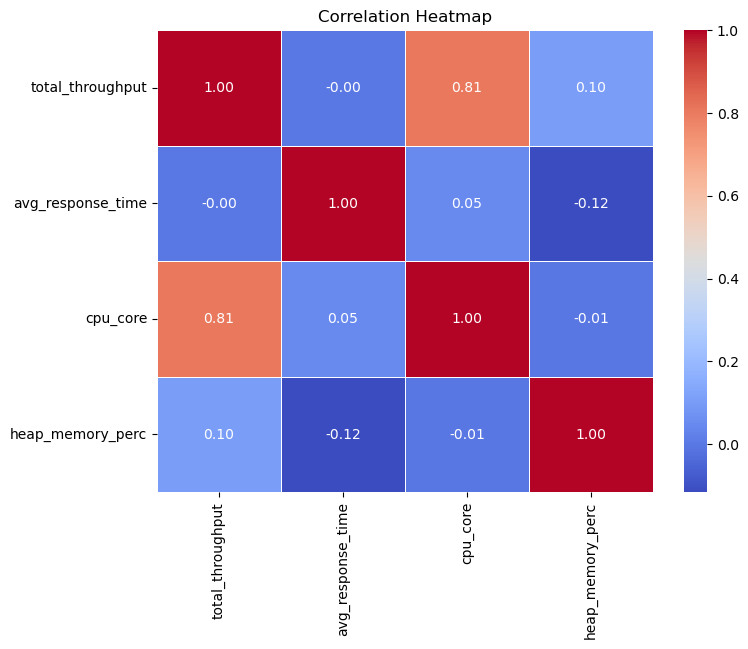

In [66]:
# Correlation matrix
final_cols = ['total_throughput','avg_response_time','cpu_core','heap_memory_perc']
corr = df[final_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Memory and API Relationship Analysis

**After Reviewing above 3 charts and the total throughput Heatmap, it clearly shows that there is no correlation with API performance and the memory. Hence our objective will remain to see how CPU usage will change based on the change in throughput.**

**Same goes with Response time too. There is no correlation between response time with CPU Core and Memory**

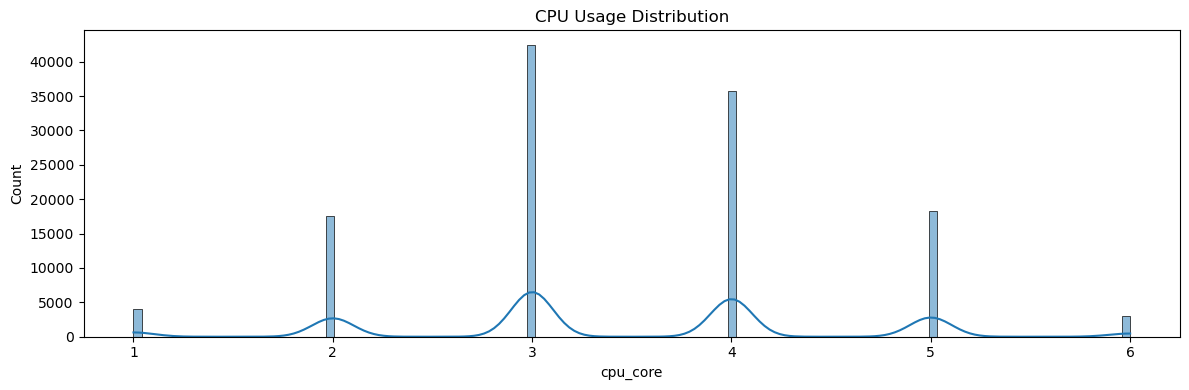

In [67]:
# Quick target distribution plots
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

sns.histplot(df["cpu_core"], kde=True, ax=ax)
ax.set_title("CPU Usage Distribution")

plt.tight_layout()
plt.show()

### Approach 1: Built a model by adding all the throughput and then predicting the values

In [68]:
# Baseline feature set
feature_cols = ['total_throughput']
X = df[feature_cols]
y = df["cpu_core"]
X.head()

,total_throughput
0,34
1,39
2,41
3,43
4,40


In [69]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
# Baseline Linear Regression pipelines
lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lin_pipe.fit(X_train, y_train)
cpu_pred = lin_pipe.predict(X_test)

def report_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{label} -> RMSE: {rmse:.3f}, MSE: {mse:.3f}")

report_metrics(y_test, cpu_pred, "CPU LinearRegression")

CPU LinearRegression -> RMSE: 0.648, MSE: 0.420


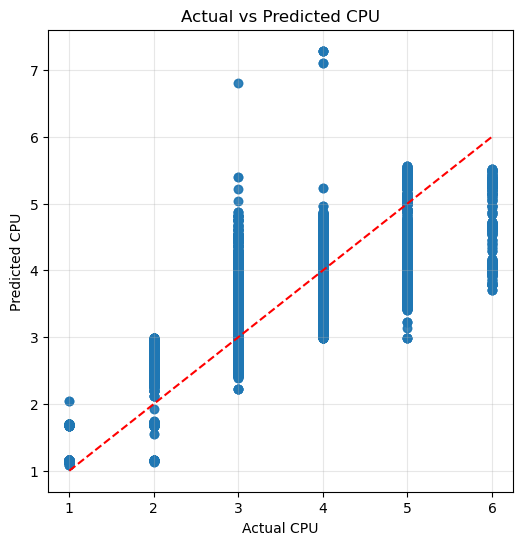

In [71]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, cpu_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual CPU")
plt.ylabel("Predicted CPU")
plt.title("Actual vs Predicted CPU")
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
# 5-fold CV 
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cpu_cv_mse = -cross_val_score(lin_pipe, X, y, scoring="neg_mean_squared_error", cv=cv)

cpu_cv_rmse = np.sqrt(cpu_cv_mse)

print("CPU CV RMSE mean=", round(cpu_cv_rmse.mean(), 3))


CPU CV RMSE mean= 0.645


### The linear regression model showed stable performance across validation methods. The 5-fold cross-validation RMSE was 0.645, which is very close to the test RMSE of 0.648, indicating consistent generalization and limited evidence of overfitting.

In [73]:
# Predict on what will happen if Graph API throughput increases by 50% as new customer is joining
max_graph_throughput = df["graph_api_throughput"].max()
avg_insert_throughput = df["insert_api_throughput"].max()
avg_search_throughput = df["search_api_throughput"].max()

print("Max Graph API throughput: ", max_graph_throughput)
print("Avg Insert API throughput: ", avg_insert_throughput)
print("Avg Search API throughput: ", avg_search_throughput)

# increase graph api throughput by 50%
new_total_throughput = (max_graph_throughput * 1.5) + avg_insert_throughput + avg_search_throughput
print("New Total Throughput: ", new_total_throughput)


new_data = pd.DataFrame({
    "total_throughput": [new_total_throughput]
})

pred_cpu = lin_pipe.predict(new_data)

print("Predicted CPU:", pred_cpu[0])

Max Graph API throughput:  552
Avg Insert API throughput:  225
Avg Search API throughput:  857
New Total Throughput:  1910.0
Predicted CPU: 12.358214626142296


### Approach 2: Built a model by using individual throughput columns and then predicting the values

In [74]:
# Baseline feature set
feature_cols = throughput_cols
X = df[feature_cols]
y = df["cpu_core"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lin_pipe.fit(X_train, y_train)
cpu_pred = lin_pipe.predict(X_test)

def report_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{label} -> RMSE: {rmse:.3f}, MSE: {mse:.3f}")

report_metrics(y_test, cpu_pred, "CPU LinearRegression")


CPU LinearRegression -> RMSE: 0.636, MSE: 0.404


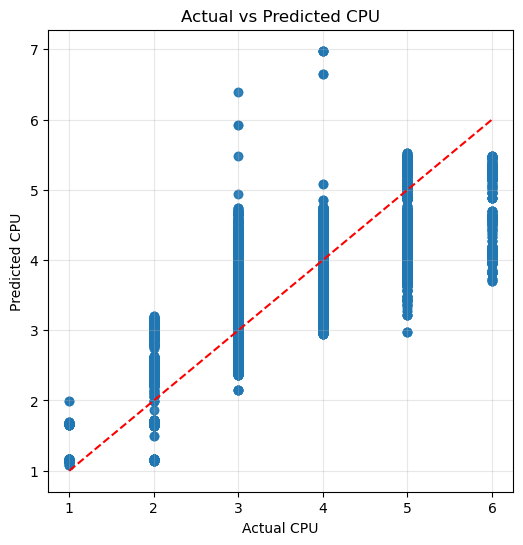

In [75]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, cpu_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual CPU")
plt.ylabel("Predicted CPU")
plt.title("Actual vs Predicted CPU")
plt.grid(True, alpha=0.3)
plt.show()

In [76]:
# Predict on what will happen if Graph API throughput increases by 50% as new customer is joining
max_graph_throughput = df["graph_api_throughput"].max()
avg_insert_throughput = df["insert_api_throughput"].max()
avg_search_throughput = df["search_api_throughput"].max()

print("Max Graph API throughput: ", max_graph_throughput)
print("Avg Insert API throughput: ", avg_insert_throughput)
print("Avg Search API throughput: ", avg_search_throughput)

# increase graph api throughput by 50%
new_data = pd.DataFrame({
    "search_api_throughput": [avg_search_throughput],
    "insert_api_throughput" : [avg_insert_throughput],
    "graph_api_throughput" : [(max_graph_throughput * 1.5)]
})

pred_cpu = lin_pipe.predict(new_data)

print("Predicted CPU:", pred_cpu[0])

Max Graph API throughput:  552
Avg Insert API throughput:  225
Avg Search API throughput:  857
Predicted CPU: 12.816044773779964


### Approach 3: Use RandomForestRegressor to compare the 2 models

In [80]:
# Example feature engineering
X = df[feature_cols]
y = df["cpu_core"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RandomForestRegressor -> RMSE: {rmse:.3f}, MSE: {mse:.3f}, R2: {r2:.3f}")


RandomForestRegressor -> RMSE: 0.083, MSE: 0.007, R2: 0.994


In [78]:
# Predict on what will happen if Graph API throughput increases by 50% as new customer is joining

pred_cpu = rf_model.predict(new_data)

print("Predicted CPU:", pred_cpu[0])

Predicted CPU: 5.89


### Linear Regression vs Random Forest Regressor

Random Forest achieved high accuracy on historical data, but it is primarily an interpolation model and does not extrapolate reliably beyond the throughput range seen during training. Since the target scenario involves a total throughput of ~1900, which is outside the observed data, Linear Regression provides a more meaningful estimate of CPU demand for this what-if capacity planning exercise.

### Conclusion

Using these predictive models, we can estimate CPU requirements under different API throughput combinations without running a new performance test for every scenario. For example, if Graph API throughput increases by 50% while the other APIs stay near their average volume, the model predicts higher CPU demand and indicates that the current CPU core limit may need to be increased. This approach can also be extended to other what-if scenarios, such as peak traffic across all APIs or a significant increase in any single API, to support infrastructure sizing and capacity planning.